In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_anthropic import ChatAnthropic
from langgraph.checkpoint.memory import MemorySaver

In [2]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [3]:
llm = ChatAnthropic(model="claude-haiku-4-5-20251001")

def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

In [4]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)

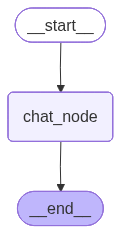

In [5]:
chatbot

In [6]:
# initial_state = {
#     'messages': [HumanMessage(content="What is the capital of India")]
# }

# chatbot.invoke(initial_state)

In [7]:
# chatbot.invoke(initial_state)['messages'][-1]

In [8]:
# chatbot.invoke(initial_state)['messages'][-1].content

In [9]:
thread_id = '1'

while True:

    user_message = input('Type here: ')

    print(f'User: {user_message}')

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break

    config = {'configurable': {'thread_id': thread_id}}
    
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)

    print(f'AI: {response["messages"][-1].content}')

User: hi my name is Nikhil
AI: Hi Nikhil! Nice to meet you. How can I help you today?
User: what is my name?
AI: Your name is Nikhil! You told me that at the beginning of our conversation.
User: can you add 10 with 100
AI: Yes! 10 + 100 = **110**
User: now divide it by 11
AI: 110 ÷ 11 = **10**
User: bye


In [10]:
chatbot.get_state(config = config)

StateSnapshot(values={'messages': [HumanMessage(content='hi my name is Nikhil', additional_kwargs={}, response_metadata={}, id='0fc522bf-cfb2-4cb7-8fa9-287c060e8c13'), AIMessage(content='Hi Nikhil! Nice to meet you. How can I help you today?', additional_kwargs={}, response_metadata={'id': 'msg_01GFnPamg26joY2bTFrannuY', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_details': None, 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 15, 'output_tokens': 21, 'output_tokens_details': None, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anthropic'}, id='lc_run--019f23e2-6a34-7c41-94ba-9263f34c6a94-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 21, 'total_